In [2]:
import pandas as pd

In [3]:
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

In [4]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
train.MSSubClass.value_counts(normalize=True).sort_values(ascending=True)

# convert the MSSubClass to categorical where normalized value counts if they are less than 0.002, set them to LOW, if the are greater than 0.002 and less than 0.20 set them to MEDIUM, and if they are greater than 0.20 set them to MEDIUM, set greater than 0.20 to HIGH

train.MSSubClass = train.MSSubClass.apply(lambda x: 0 if x < 0.002 else 1 if x > 0.002 and x < 0.20 else 2)

test.MSSubClass = test.MSSubClass.apply(lambda x: 0 if x < 0.002 else 1 if x > 0.002 and x < 0.20 else 2)


In [6]:
train.MSZoning.value_counts(normalize=True)

MSZoning
RL         0.788356
RM         0.149315
FV         0.044521
RH         0.010959
C (all)    0.006849
Name: proportion, dtype: float64

In [7]:
# merge FV RH C (all) into C
train.MSZoning.replace({'FV': 'C', 'RH': 'C', 'C (all)': 'C'}, inplace=True)

test.MSZoning.replace({'FV': 'C', 'RH': 'C', 'C (all)': 'C'}, inplace=True)

/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/811255220.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.MSZoning.replace({'FV': 'C', 'RH': 'C', 'C (all)': 'C'}, inplace=True)
/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/811255220.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we

In [8]:
train.MSZoning.value_counts(normalize=True)

MSZoning
RL    0.788356
RM    0.149315
C     0.062329
Name: proportion, dtype: float64

In [9]:
# LotFrontage

train.LotFrontage.value_counts()

LotFrontage
60.0     143
70.0      70
80.0      69
50.0      57
75.0      53
        ... 
137.0      1
141.0      1
38.0       1
140.0      1
46.0       1
Name: count, Length: 110, dtype: int64

In [10]:
train.LotArea.value_counts()

LotArea
7200     25
9600     24
6000     17
9000     14
8400     14
         ..
14601     1
13682     1
4058      1
17104     1
9717      1
Name: count, Length: 1073, dtype: int64

In [11]:
print(train.Street.value_counts)

# 90% the same value so going to delete the columns

train.drop('Street', axis=1, inplace=True)
test.drop('Street', axis=1, inplace=True)

<bound method IndexOpsMixin.value_counts of 0       Pave
1       Pave
2       Pave
3       Pave
4       Pave
        ... 
1455    Pave
1456    Pave
1457    Pave
1458    Pave
1459    Pave
Name: Street, Length: 1460, dtype: object>


/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/1860085656.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.Alley.replace({'Grvl': 0, 'Pave': 1}, inplace=True)
/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/1860085656.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting

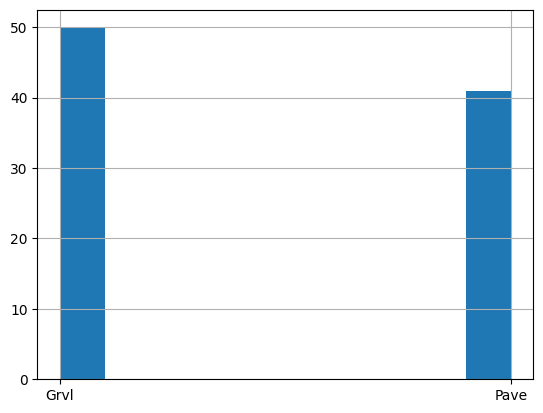

In [12]:
train.Alley.hist()

# label encode the column

train.Alley.replace({'Grvl': 0, 'Pave': 1}, inplace=True)
test.Alley.replace({'Grvl': 0, 'Pave': 1}, inplace=True)

In [13]:
train.LotShape.value_counts(normalize=True)

# label encode the column

train.LotShape.replace({'Reg': 0, 'IR1': 1, 'IR2': 2, 'IR3': 3}, inplace=True)
test.LotShape.replace({'Reg': 0, 'IR1': 1, 'IR2': 2, 'IR3': 3}, inplace=True)

/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/3579365057.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.LotShape.replace({'Reg': 0, 'IR1': 1, 'IR2': 2, 'IR3': 3}, inplace=True)
/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/3579365057.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.

In [14]:
train.LandContour.value_counts()

# label encode the column

train.LandContour.replace({'Lvl': 0, 'Bnk': 1, 'HLS': 2, 'Low': 3}, inplace=True)
test.LandContour.replace({'Lvl': 0, 'Bnk': 1, 'HLS': 2, 'Low': 3}, inplace=True)

/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/3533389730.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.LandContour.replace({'Lvl': 0, 'Bnk': 1, 'HLS': 2, 'Low': 3}, inplace=True)
/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/3533389730.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('futu

In [15]:
train.Utilities.value_counts()

# drop this column as it has only 1 value

train.drop('Utilities', axis=1, inplace=True)
test.drop('Utilities', axis=1, inplace=True)

In [16]:
train.LotConfig.value_counts()

# label encode the column

train.LotConfig.replace({'Inside': 0, 'Corner': 1, 'CulDSac': 2, 'FR2': 3, 'FR3': 3}, inplace=True)
test.LotConfig.replace({'Inside': 0, 'Corner': 1, 'CulDSac': 2, 'FR2': 3, 'FR3': 3}, inplace=True)

/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/3516807132.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.LotConfig.replace({'Inside': 0, 'Corner': 1, 'CulDSac': 2, 'FR2': 3, 'FR3': 3}, inplace=True)
/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/3516807132.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `p

In [17]:
train.LandSlope.value_counts()

# label encode the column

train.LandSlope.replace({'Gtl': 0, 'Mod': 1, 'Sev': 2}, inplace=True)
test.LandSlope.replace({'Gtl': 0, 'Mod': 1, 'Sev': 2}, inplace=True)

/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/4278834061.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.LandSlope.replace({'Gtl': 0, 'Mod': 1, 'Sev': 2}, inplace=True)
/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/4278834061.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent

In [19]:
tvc = train.Neighborhood.value_counts(normalize=True)

# get all the labels which have greater than 0.01 proportion and replace the others with 'Others', store the neighborhood in a list


labels = tvc[tvc > 0.01].index
train.Neighborhood.replace({label: 'Others' for label in train.Neighborhood.unique() if label not in labels}, inplace=True)
test.Neighborhood.replace({label: 'Others' for label in test.Neighborhood.unique() if label not in labels}, inplace=True)


#label encode the column using sklearn

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train.Neighborhood = le.fit_transform(train.Neighborhood)
test.Neighborhood = le.transform(test.Neighborhood)

train.Neighborhood.value_counts(normalize=True)


/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/1809546652.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.Neighborhood.replace({label: 'Others' for label in train.Neighborhood.unique() if label not in labels}, inplace=True)
/var/folders/qw/h58s1rpd2c76jh0cn440ynbm0000gn/T/ipykernel_4034/1809546652.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never

Neighborhood
11    0.154110
4     0.102740
15    0.077397
6     0.068493
20    0.058904
7     0.054110
14    0.052740
18    0.050685
12    0.050000
19    0.040411
2     0.039726
5     0.034932
10    0.033562
13    0.028082
22    0.026027
8     0.025342
3     0.019178
21    0.017123
17    0.017123
16    0.015068
9     0.011644
0     0.011644
1     0.010959
Name: proportion, dtype: float64

In [20]:
train.Condition1.value_counts(normalize=True)

Condition1
Norm      0.863014
Feedr     0.055479
Artery    0.032877
RRAn      0.017808
PosN      0.013014
RRAe      0.007534
PosA      0.005479
RRNn      0.003425
RRNe      0.001370
Name: proportion, dtype: float64